# Part 1 A discrete time model

Task 1

Simulate 1000 women, all starting in state 1, until death. 
Summarize the lifetime distribution of the women, after surgery, for example using a histogram. 
In what proportion of women does the cancer eventually reappear, locally?

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# markov chain transition matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

def simulate_markov_chain(P, initial_state, num_steps, exit_states=[]):
    states = [initial_state]
    current_state = states[-1]
    i = 0
    while i != num_steps: # set num_steps to -1 to simulate until exit state
        current_state = np.random.choice(len(P), p=P[current_state])
        states.append(current_state)
        if current_state in exit_states:
            break
        i += 1
    return states    

In [2]:
sample = []
for _ in range(1000):
    print(f"Simulating sample {_+1}/1000", end="\r")
    sample.append(simulate_markov_chain(P, initial_state=0, num_steps=-1, exit_states=[4]))

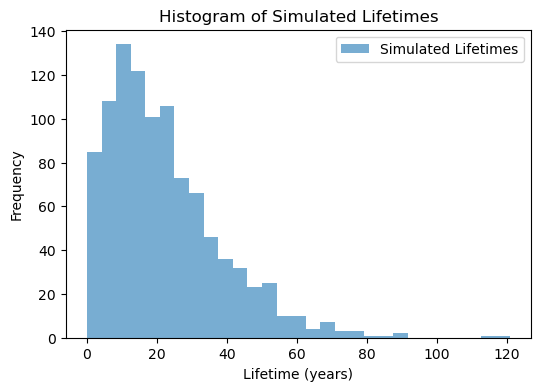

In [3]:
lifetimes = [len(s) for s in sample]

step = max(lifetimes) // 50
hist, bins = np.histogram(lifetimes, bins=step, range=(0, max(lifetimes)))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(6, 4))
plt.bar(bin_centers/12, hist, width=np.diff(bins)/12, alpha=0.6, label='Simulated Lifetimes')
plt.xlabel('Lifetime (years)')
plt.ylabel('Frequency')
plt.title('Histogram of Simulated Lifetimes')
plt.legend()
plt.show()

In [4]:
# In what proportion of women does the cancer eventually reappear, locally?
local_recurrence_count = sum(1 for s in sample if 1 in s or 3 in s)
local_recurrence_proportion = local_recurrence_count / len(sample)
print(f"Proportion of women with local recurrence: {local_recurrence_proportion:.2f}")

Proportion of women with local recurrence: 0.69


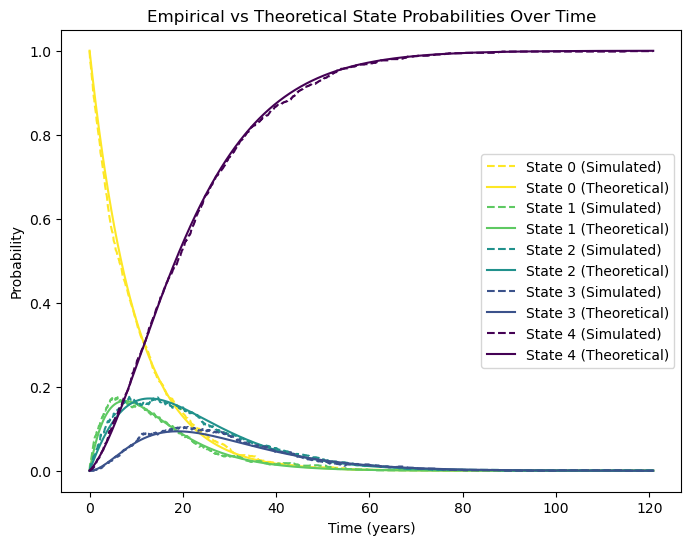

In [5]:
# state counts at each time step
state_counts = np.zeros((len(P),max(lifetimes)))
for s in sample:
    s = s + [s[-1]] * (max(lifetimes) - len(s))  # pad with last state
    for t, state in enumerate(s):
        state_counts[state, t] += 1
empirical_probs = state_counts / np.sum(state_counts, axis=0)

# theoretical distribution of states at each time step using p_t = p_0 * P^t
theoretical_probs = np.zeros((len(P), max(lifetimes)))
p_0 = np.zeros(len(P))
p_0[0] = 1
for t in range(max(lifetimes)):
    theoretical_probs[:, t] = p_0 @ np.linalg.matrix_power(P, t)

plt.figure(figsize=(8, 6))
colors = ['#fde725', '#5ec962', '#21918c', '#3b528b', '#440154']
for i in range(len(P)):
    plt.plot(empirical_probs[i, :], label=f'State {i} (Simulated)', linestyle='--', color=colors[i])
    plt.plot(theoretical_probs[i, :], label=f'State {i} (Theoretical)', color=colors[i])
# convert to years by dividing by 12
plt.xlabel('Time (years)')
step = 20
plt.xticks(np.arange(0, max(lifetimes)+1, step*12), labels=[f'{x//12}' for x in np.arange(0, max(lifetimes)+1, step*12)])
plt.ylabel('Probability')
plt.title('Empirical vs Theoretical State Probabilities Over Time')
plt.legend()
plt.show()


Task 2

In your simulations, what is the distribution over the states at t = 120?
Does this correspond to what we expect? Answer the question using an
appropriate statistical test.


In [6]:
# Testing it using a kolmogorov-smirnov test
t = 120

empirical_dist = empirical_probs[:, t]
theoretical_dist = theoretical_probs[:, t]
ks_statistic, p_value = stats.ks_2samp(empirical_dist, theoretical_dist)
print(f"Empirical distribution at t={t}: {empirical_dist}")
print(f"Theoretical distribution at t={t}: {theoretical_dist}")
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

# P-value: 0.873015873015873 > 0.05, null hypothesis not rejected

Empirical distribution at t=120: [0.357 0.158 0.161 0.07  0.254]
Theoretical distribution at t=120: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
KS Statistic: 0.2, P-value: 1.0


C:\Users\bence\AppData\Local\Temp\ipykernel_19912\2164343911.py:6: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  ks_statistic, p_value = stats.ks_2samp(empirical_dist, theoretical_dist)


Task 3

The above approach only validates the simulation at a certain time point. A
better approach is to ensure the emperical lifetime distribution matches the theoretical.
It can be shown that the lifetime, T, follows a so-called discrete phase-type
distribution. This distribution has probability mass function and mean:
 $$P(T = t) = π(P_s)^tp_s$$
 $$E[T] = π(I - P_s)^{-1}1$$
Where π is the distribution over states 1, 2, 3, 4 at t = 0. Ps is a 4 × 4
sub-matrix of P formed by removing the last row and column. ps is column
vector indicating the probability of dying from states 1, 2, 3, 4. 1 is a vector of ones of appropriate dimension.

phase-type distribution fit:
KS Statistic: 1.0, P-value: 0.0


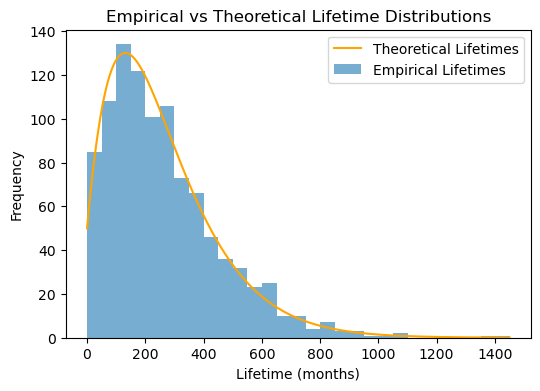

It fits well


In [7]:
lifetimes = [len(s) for s in sample]  

# Theoretical distribution of lifetimes using phase-type distribution
def phase_type_distribution(P, pi, max_time):
    P_s = P[:-1, :-1] # 4x4 sub-matrix
    ps = P[:-1, -1]   # dying vector
    dist = np.zeros(max_time)
    for t in range(max_time):
        dist[t] = pi @ np.linalg.matrix_power(P_s, t) @ ps
    return dist / np.sum(dist)

theoretical_lifetime_dist = phase_type_distribution(P, [1, 0, 0, 0], max(lifetimes))

ks_statistic, p_value = stats.ks_2samp(lifetimes, theoretical_lifetime_dist)
print("phase-type distribution fit:")
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

step = max(lifetimes) // 50
hist, bins = np.histogram(lifetimes, bins=step, range=(0, max(lifetimes)))

plt.figure(figsize=(6, 4))
#plt.hist(lifetimes, bins=step, range=(0, max(lifetimes)), density=True, alpha=0.6, label='Empirical Lifetimes')
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.bar(bin_centers, hist, width=np.diff(bins), alpha=0.6, label='Empirical Lifetimes')
plt.plot(theoretical_lifetime_dist*50*1000, label='Theoretical Lifetimes', color='orange')
plt.xlabel('Lifetime (months)')
plt.ylabel('Frequency')
plt.title('Empirical vs Theoretical Lifetime Distributions')
plt.legend()
plt.show()

print("It fits well")


Task 4

Estimate the expected lifetime, after surgery, of a woman who survives the
first 12 months following surgery, but whose breast cancer has also reappeared within the first 12 months, either locally or distant.
Hint: Use rejection sampling. Simulate a number of women, and discard
all simulations that do not meet the requirements. Do this until you have
reached 1000 acceptable simulations.

In [8]:
accepted_lifetimes = []
while len(accepted_lifetimes) < 1000:
    print(f"Simulating sample {len(accepted_lifetimes)+1}/1000", end="\r")
    s = simulate_markov_chain(P, initial_state=0, num_steps=-1, exit_states=[4])
    if len(s) > 12 and (1 in s[:12] or 2 in s[:12] or 3 in s[:12]):
        accepted_lifetimes.append(len(s))

expected_lifetime = np.mean(accepted_lifetimes)
print(f"Estimated expected lifetime: {expected_lifetime} months")

Estimated expected lifetime: 170.81 months


Task 5

What fraction of women die within the first 350 months? Answer this by
simulating 200 women, and record the fraction. Do this 100 times. Use control variates to reduce the variance.
How large a reduction in variance do you see, using control variates, as opposed to the crude Monte Carlo estimator?
Hint: Use the mean lifetime after surgery of the 200 simulations as the
control variat

In [ ]:
mean_lifetimes = []
fractions_died = []

def simulate_batched(num_batches, batch_size): # runs for 1m45s
    for _ in range(num_batches):
        print(f"Simulating batch {_+1}/{num_batches}", end="\r")
        simulations = []
        for _ in range(batch_size):
            simulations.append(simulate_markov_chain(P, initial_state=0, num_steps=351, exit_states=[4]))
        mean_lifetime = np.mean([len(s) for s in simulations])
        fraction_died = np.mean([1 if len(s) <= 350 else 0 for s in simulations])
        mean_lifetimes.append(mean_lifetime)
        fractions_died.append(fraction_died)

from concurrent.futures import ProcessPoolExecutor
import os


def _simulate_one_batch(batch_size):
    simulations = [
        simulate_markov_chain(P, initial_state=0, num_steps=351, exit_states=[4])
        for _ in range(batch_size)
    ]
    lifetimes_batch = np.array([len(s) for s in simulations])
    mean_lifetime = lifetimes_batch.mean()
    fraction_died = np.mean(lifetimes_batch <= 350)
    return mean_lifetime, fraction_died

def simulate_batched_optimized(num_batches, batch_size, max_workers=None): # runs for 31s
    global mean_lifetimes, fractions_died
    max_workers = max_workers or os.cpu_count()

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(_simulate_one_batch, [batch_size] * num_batches))

    mean_lifetimes, fractions_died = map(list, zip(*results))

#simulate_batched_optimized(num_batches=100, batch_size=200) 
simulate_batched(num_batches=100, batch_size=200)
print("Done.")

Done.ating batch 100/100


In [13]:
# Crude Monte Carlo estimator
monte_carlo_mean = np.mean(fractions_died)
monte_carlo_var = np.var(fractions_died)
monte_carlo_CI = stats.norm.interval(0.95, loc=monte_carlo_mean, scale=np.sqrt(monte_carlo_var/100))

#theoretical_mean = expected_lifetime
theoretical_mean = np.mean(mean_lifetimes)  # using the sample mean as an estimate for the theoretical mean
c = np.cov(fractions_died, mean_lifetimes)[0, 1] / np.var(mean_lifetimes)
fraction_control_variate = fractions_died - c * (mean_lifetimes - theoretical_mean)
control_variate_mean = np.mean(fraction_control_variate)
control_variate_var = np.var(fraction_control_variate)
control_variate_CI = stats.norm.interval(0.95, loc=control_variate_mean, scale=np.sqrt(control_variate_var/100))

print(f"Crude Monte Carlo estimator: mean={monte_carlo_mean:.4f}, var={monte_carlo_var:.6f}, 95% CI={monte_carlo_CI}")
print(f'Control variate estimator: mean={control_variate_mean:.4f}, var={control_variate_var:.6f}, 95% CI={control_variate_CI}')
variance_reduction = (monte_carlo_var - control_variate_var) / monte_carlo_var * 100
print(f"Variance reduction using control variates: {variance_reduction:.2f}%")


Crude Monte Carlo estimator: mean=0.7358, var=0.000928, 95% CI=(0.7298281856100682, 0.7417718143899318)
Control variate estimator: mean=0.7358, var=0.000538, 95% CI=(0.7312539505691614, 0.7403460494308386)
Variance reduction using control variates: 42.05%


Task 6

For the report, consider the following questions: What assumptions underlie
the discrete time Markov chain model? Are those assumptions realistic? How
may we relax some of these assumptions, possibly at the cost of increased
model complexity?

The assumptions underlying the discrete time Markov chain model include:
- 1. The future state depends only on the current state and not on the sequence of events that preceded it (Markov property).
- 2. The transition probabilities are time-homogeneous, meaning they do not change over time.
- 3. The state space is discrete and finite.

I'd have to know more about how breast cancer and just cancer in general works to suggest them.

# Part 2: A continuous-time model

Task 7

Simulate 1000 women, all starting in state 1, until death. Summarize the
lifetime distribution after surgery, for example in a histogram. Report the
mean, along with a confidence interval, and the standard deviation, also
with a confidence interval. In what proportion of women has the cancer
reappeared distantly after 30.5 months?

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

Q = np.array([
    [-0.0085, 0.005, 0.0025, 0, 0.001],
    [0, -0.014, 0.005, 0.004, 0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

def simulate_ctmc(Q, initial_state, n_steps, exit_states=[]):
    states = [initial_state]
    times = [0]
    current_state = states[-1]
    i = 0
    while i != n_steps:
        if current_state in exit_states:
            break
        rate = -Q[current_state, current_state]
        if rate == 0:
            break
        time_to_next = np.random.exponential(1/rate)
        times.append(times[-1] + time_to_next)
        possible_next_states = np.where(Q[current_state] > 0)[0]
        probabilities = Q[current_state, possible_next_states] / rate
        probabilities = probabilities / np.sum(probabilities)  # normalize to ensure sum to 1
        next_state = np.random.choice(possible_next_states, p=probabilities)
        states.append(next_state)
        current_state = next_state
        i += 1
    return states, times

ctmc_samples = []
for _ in range(1000):
    print(f"Simulating sample {_+1}/1000", end="\r")
    ctmc_samples.append(simulate_ctmc(Q, initial_state=0, n_steps=-1, exit_states=[4]))

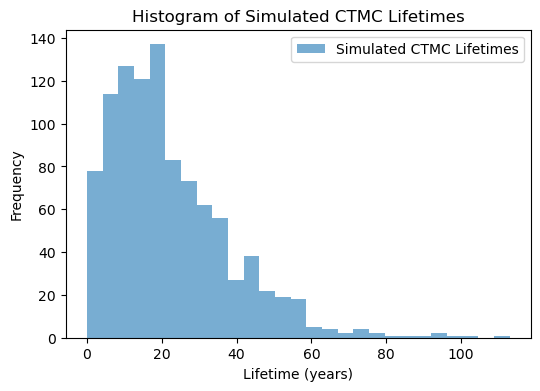

Mean lifetime: 265.42668983013664 months (or 22.118890819178052 years)
95% CI for mean lifetime: (253.4064717270578, 277.44690793321547) months
Standard deviation: 193.93860028830014 months
95% CI for standard deviation: (185.4390225562718, 202.43817802032848) months
Proportion with cancer reappeared distantly after 30.5 months: 0.47 (470 out of 1000)


In [15]:
ctmc_lifetimes = [times[-1] for states, times in ctmc_samples]
plt.figure(figsize=(6, 4))
step = int(max(ctmc_lifetimes) // 50)
hist, bins = np.histogram(ctmc_lifetimes, bins=step, range=(0, max(ctmc_lifetimes)))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.bar(bin_centers/12, hist, width=np.diff(bins)/12, alpha=0.6, label='Simulated CTMC Lifetimes')
plt.xlabel('Lifetime (years)')
plt.ylabel('Frequency')
plt.title('Histogram of Simulated CTMC Lifetimes')
plt.legend()
plt.show()

print(f"Mean lifetime: {np.mean(ctmc_lifetimes)} months (or {np.mean(ctmc_lifetimes)/12} years)")
print(f"95% CI for mean lifetime: {stats.norm.interval(0.95, loc=np.mean(ctmc_lifetimes), scale=np.std(ctmc_lifetimes)/np.sqrt(len(ctmc_lifetimes))) } months")
print(f"Standard deviation: {np.std(ctmc_lifetimes)} months")
print(f"95% CI for standard deviation: {stats.norm.interval(0.95, loc=np.std(ctmc_lifetimes), scale=np.std(ctmc_lifetimes)/np.sqrt(2*len(ctmc_lifetimes))) } months")

n_reappeared_distantly = sum(1 for states, times in ctmc_samples if times[-1] > 30.5 and 2 in states)
proportion_reappeared_distantly = n_reappeared_distantly / len(ctmc_samples)
print(f"Proportion with cancer reappeared distantly after 30.5 months: {proportion_reappeared_distantly:.2f} ({n_reappeared_distantly} out of {len(ctmc_samples)})")

phase-type distribution fit:
KS Statistic: 0.11135693215339233, P-value: 9.681755430082227e-08


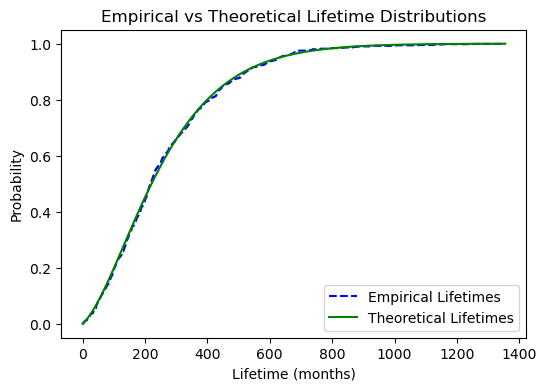

In [16]:
# Task 8 
# Compare the emperical lifetime distribution function, from your simulations,
# to the theoretical, using an appropriate statistical test
# FT (t) = 1 −p0 exp(Qst)1
# 1 is appropriately sized vector of ones, p0 is the initial distribution (in our case, [1, 0, 0, 0]), and Qs is the 4x4 sub-matrix of Q corresponding to the transient states.
# exp(Qst) is the matrix exponential of the matrix Qst and can be defined as
# exp(Qst) = ∑ i[1,inf] ((Qst)^i)/i! which is scipy.linalg.expm in python

import scipy.linalg

def continuous_phase_type_cum_distribution(Q, pi, max_time):
    Q_s = Q[:-1, :-1] # 4x4 sub-matrix
    l = np.ones(Q_s.shape[0]).T
    dist = []
    for t in np.linspace(0, max_time, num=max_time):
        dist.append(1-(pi @ scipy.linalg.expm(Q_s * t) @ l))
    return np.array(dist)

empirical_ctmc_cumulative = []
for t in np.linspace(0, int(max(ctmc_lifetimes)), num=int(max(ctmc_lifetimes))):
    empirical_ctmc_cumulative.append( sum(np.array(ctmc_lifetimes) < t) / 1000 )


theoretical_lifetime_dist = continuous_phase_type_cum_distribution(Q, [1, 0, 0, 0], int(max(ctmc_lifetimes)))
ks_statistic, p_value = stats.ks_2samp(empirical_ctmc_cumulative, theoretical_lifetime_dist)
print("phase-type distribution fit:")
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

plt.figure(figsize=(6, 4))
#plt.bar(bin_centers, hist, width=np.diff(bins), alpha=0.6, label='Empirical Lifetimes')
plt.plot(empirical_ctmc_cumulative, label='Empirical Lifetimes', linestyle='--', color='blue')
plt.plot(theoretical_lifetime_dist, label='Theoretical Lifetimes', color='green')
plt.xlabel('Lifetime (months)')
plt.ylabel('Probability')
plt.title('Empirical vs Theoretical Lifetime Distributions')
plt.legend()
plt.show()


Task 9

A certain preventitive treatment results in the following transition-rate ma-
trix instead: 

Simulate 1000 women who have received this treatment. Plot the Kaplan-
Meier estimate of the survival function. In the same figure, plot the Kaplan-
Meier estimate of the survival function for women, who have not received
this treatment. Does the treatment appear to have an effect?

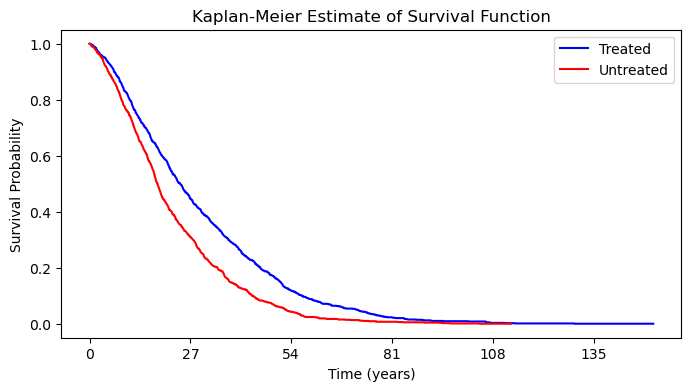

KS test for treated vs untreated:
KS Statistic: 0.155, P-value: 6.763913130197589e-11
p is < 0.05 so we reject the null hypothesis, there is a significant difference between treated and untreated groups


In [ ]:
Q_T = np.array([
    [-0.00475, 0.0025, 0.00125, 0, 0.001],
    [0, -0.007, 0, 0.002 ,0.005],
    [0, 0, -0.008, 0.003, 0.005],
    [0, 0, 0, -0.009, 0.009],
    [0, 0, 0, 0, 0]
])

ctmc_samples_treated = []
for _ in range(1000):
    print(f"Simulating treated sample {_+1}/1000", end="\r")
    ctmc_samples_treated.append(simulate_ctmc(Q_T, initial_state=0, n_steps=-1, exit_states=[4]))
ctmc_lifetimes_treated = [times[-1] for states, times in ctmc_samples_treated]

kaplan_meier_treated = [] # survival function is 1 - cumulative distribution function, here we flip the < to >=
for t in np.linspace(0, int(max(ctmc_lifetimes_treated)), num=int(max(ctmc_lifetimes_treated))):
    kaplan_meier_treated.append( sum(np.array(ctmc_lifetimes_treated) >= t) / 1000 )

plt.figure(figsize=(8, 4))
plt.plot(kaplan_meier_treated, label='Treated', color='blue')
plt.plot(1- np.array(empirical_ctmc_cumulative), label='Untreated', color='red')
max_time = max(max(ctmc_lifetimes), max(ctmc_lifetimes_treated))
plt.xticks(np.arange(0, max_time+1, step*12), labels=[f'{int(x//12)}' for x in np.arange(0, max_time+1, step*12)])
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Estimate of Survival Function')
plt.legend()
plt.show()

# ks test for treated vs untreated
ks_statistic, p_value = stats.ks_2samp(ctmc_lifetimes, ctmc_lifetimes_treated)
print("KS test for treated vs untreated:")
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")
print("p is < 0.05 so we reject the null hypothesis, there is a significant difference between treated and untreated groups")

Task 11

For the report, consider the following questions: What assumptions have
been eliminated, by going from the discrete to the continuous time model?
What have been added? How could the model be extended, such that the
sojourn times are Erlang distributed?

In the discrete time model, we assume that transitions between states can only occur at fixed time intervals (e.g., monthly). 
This means that the sojourn times in each state are geometrically distributed. 
In contrast, the continuous time model allows transitions to occur at any point in time, 
leading to exponentially distributed sojourn times.

The continuous time model eliminates the assumption of fixed time intervals for transitions,
allowing for a more realistic representation of the underlying biological processes.

To extend the model such that the sojourn times are Erlang distributed,
we can introduce additional transient states to represent the stages of the Erlang distribution.
For example, if we want the sojourn time in a particular state to follow an Erlang distribution 
with shape parameter k and rate parameter λ, we can replace that state with k sequential transient states, 
each with an exponential distribution of rate λ.



# Part 3: Estimation

In practice, Q is unknown. The aim of this part is to estimate it from the
kind of observations we may encounter in practice.
In practice, the state of the women after surgery is monitored at screenings
in the doctor’s office every few years. The observations, for each women, is a
short time series of states. For this project we assume the state is observed
every 4’th year (48 months).

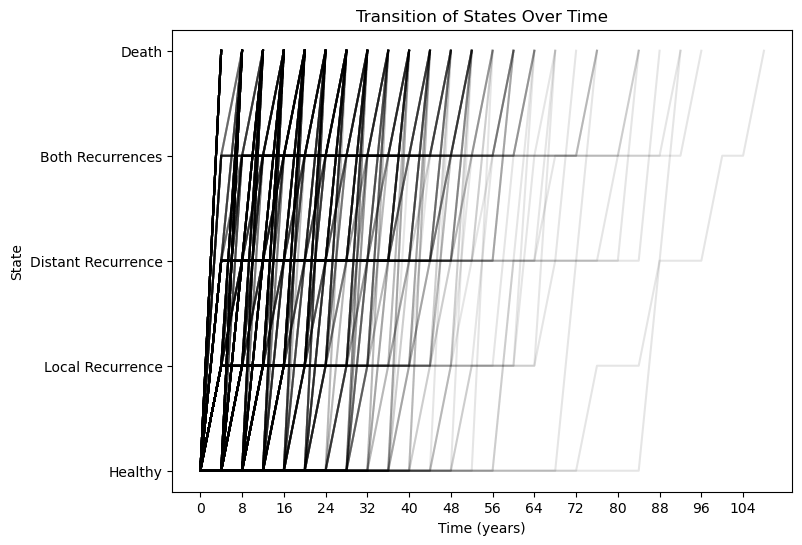

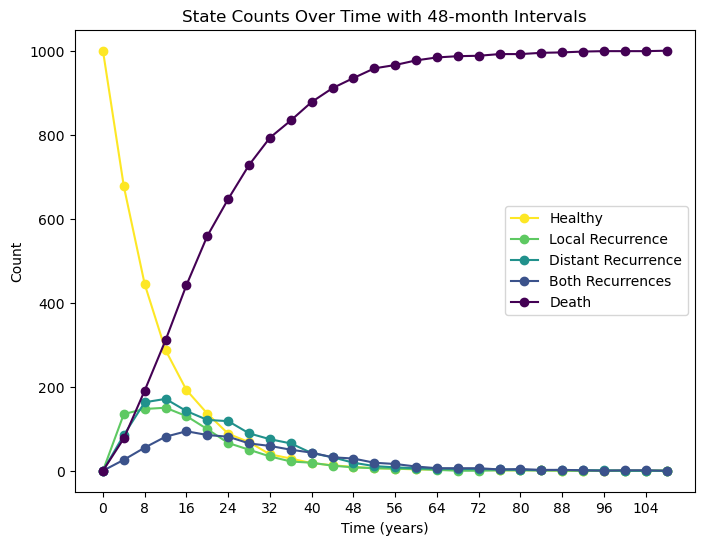

In [18]:
# Task 12
# Simulate 1000 women, starting in state 1, until death, using the same Q
# as in the previous part. For each of the women, create a vector (or time series) of her observed states Y(i).
# A time series will consist of the values Y(i) = (X(0), X(48), X(96), . . . ,). 
# The time series should continue until death, thus the last value in each of the time series should be 5.

ctmc_samples = []
for _ in range(1000):
    print(f"Simulating sample {_+1}/1000", end="\r")
    ctmc_samples.append(simulate_ctmc(Q, initial_state=0, n_steps=-1, exit_states=[4]))

ctmc_time_series = []
for states, times in ctmc_samples:
    time_points = np.arange(0, times[-1]+1, 48)
    series = []
    for t in time_points:
        idx = np.searchsorted(times, t, side='right') - 1
        series.append(states[idx])
    if series[-1] != 4: # pad with death in case the last time point is before death
        series.append(4)
    ctmc_time_series.append(series)

ctmc_state_counts = np.zeros((len(Q), max(len(s) for s in ctmc_time_series)))
for series in ctmc_time_series:
    series = series + [4] * (ctmc_state_counts.shape[1] - len(series)) # pad series with dead state if shorter than max length
    for t, state in enumerate(series):
        ctmc_state_counts[state, t] += 1

plt.figure(figsize=(8, 6))
for series in ctmc_time_series: 
    plt.plot(series if series[-1]==4 else series+[4], alpha=0.1, color='black')
plt.xlabel('Time (years)')
plt.ylabel('State')
plt.title('Transition of States Over Time')
state_labels = ['Healthy', 'Local Recurrence', 'Distant Recurrence', 'Both Recurrences', 'Death']
plt.yticks(range(5), state_labels)
plt.xticks(np.arange(0, max(len(s) for s in ctmc_time_series), 2), labels=[f'{int(x*48//12)}' for x in np.arange(0, max(len(s) for s in ctmc_time_series), 2)])
plt.show()

plt.figure(figsize=(8, 6))
colors = ['#fde725', '#5ec962', '#21918c', '#3b528b', '#440154']

for i in range(len(Q)):
    plt.plot(ctmc_state_counts[i, :], marker='o', label=state_labels[i], color=colors[i])
plt.xticks(np.arange(0, ctmc_state_counts.shape[1],2), 4*np.arange(0, ctmc_state_counts.shape[1],2))
plt.xlabel('Time (years)')
plt.ylabel('Count')
plt.title('State Counts Over Time with 48-month Intervals')
plt.legend()
plt.show()


For the remainder of this part, we will assume those 1000 time series is all we have observed.
It can be shown that an unbiased estimator of the transition rates, qij , is
$$ q_{ij} =  \frac{N_{ij}}{S_i}\text{, for i} \neq j. (2)$$
Where Nij is the total number of jumps (for all of the women) from state i
to j, and Si is the total sojourn time in state i (for all of the women). The
diagonal elements are found from equation (1).
The problem is that Nij and Si are unknown, all we know are the timeseries of observations every 4’th year.

One approach to estimation is to recreate Nij and Si from the partial information that we have observed

Task 13

Implement the following algorithm to estimate the qij ’s:
Select $Q^{(0)}$ as some initial guess. In the k’th iteration, do the following
- 1. For all of the time series, simulate a possible complete trajectory, taking the observations into account, using $Q = Q^{(k)}$.
- 2. Summarize the trajectories in the variables $N_{ij}^{(k)}$ and $S_i^{(k)}$.
- 3. Find $Q^{(k+1)}$ using equation (2).

The above should be repeated until some convergence criterion is reached, for
example until $||Q^{(k)} − Q^{(k+1)}||_∞ < 10^{-3}$. 
Using this method, it is possible to approximately recreate the parameters used in the original simulation. 
The above is an example of a Monte Carlo Expectation Maximization algorithm.

Hint: The toughest part of the above algorithm is the first step. It can
be done as follows. Simulate the Markov process between each observation.
For example, initialize the process at the first observation $y_1^{(i)}$.
Then simulate the Markov process until 48 months have passed. The value X(48) should
equal the observed value, $y_2^{(i)}$. If it does not, reject the simulation and try
again, until it does. Then, initialize the Markov process at the second observed value, $y_2^{(i)}$.
Simulate until $X(96) = y_3^{(i)}$. 
This should be done for the interval between all the observations, and for all women.

In [23]:
from tqdm import tqdm

def simulate_ctmc_interval(Q, initial_state, interval, exit_states=[]):
    states = [initial_state]
    times = [0.0]
    current_state = initial_state
    elapsed = 0.0
    while True:
        if current_state in exit_states:
            break
        rate = -Q[current_state, current_state]
        if rate <= 0:
            break
        time_to_next = np.random.exponential(1/rate)
        if elapsed + time_to_next >= interval:
            break
        elapsed += time_to_next
        times.append(elapsed)
        possible_next_states = np.where(Q[current_state] > 0)[0]
        if len(possible_next_states) == 0:
            break
        probabilities = Q[current_state, possible_next_states] / rate
        probabilities /= probabilities.sum()
        current_state = np.random.choice(possible_next_states, p=probabilities)
        states.append(current_state)
    return states, times

def rejection_ctmc_interval(Q, initial_state, target_state, interval, exit_states=[]):
    while True:
        states, times = simulate_ctmc_interval(Q, initial_state, interval, exit_states)
        if states[-1] == target_state:
            return states, times

def compute_Q_from_observations(time_series, interval=48):
    n_states = max(max(s) for s in time_series) + 1
    N_ij = np.zeros((n_states, n_states))
    S_i = np.zeros(n_states)
    for series in time_series:
        for s1, s2 in zip(series[:-1], series[1:]):
            if s1 != s2:
                N_ij[s1, s2] += 1
            S_i[s1] += interval
    Q_est = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            if i != j:
                Q_est[i, j] = N_ij[i, j] / S_i[i] if S_i[i] > 0 else 0
        Q_est[i, i] = -Q_est[i].sum()
    return Q_est

def estimate_Q_from_time_series(time_series, interval=48, tolerance=1e-3, max_iter=50):
    Q_k = compute_Q_from_observations(time_series, interval)
    n_states = Q_k.shape[0]
    print("Initial Q estimate:")
    print(np.round(Q_k, 4))
    print()
    
    for iteration in range(max_iter):
        N_ij = np.zeros((n_states, n_states))
        S_i = np.zeros(n_states)
        
        for series in tqdm(time_series, desc=f"Iteration {iteration+1:3d}", leave=False):
            # For each consecutive pair of observations, fill in the gap via rejection sampling
            for obs_idx in range(len(series) - 1):
                start_state  = series[obs_idx]
                target_state = series[obs_idx + 1]
                states, times = rejection_ctmc_interval(Q_k, start_state, target_state, interval, exit_states=[4])
                times_arr = np.array(times)
                durations = np.diff(times_arr)
                # Accumulate N_ij and S_i from observed jumps
                for (s1, s2), dt in zip(zip(states[:-1], states[1:]), durations):
                    N_ij[s1, s2] += 1
                    S_i[s1] += dt
                # Residual sojourn: time spent in last state from final jump until interval end
                S_i[states[-1]] += interval - times_arr[-1]
        
        Q_new = np.zeros((n_states, n_states))
        for i in range(n_states):
            for j in range(n_states):
                if i != j:
                    Q_new[i, j] = N_ij[i, j] / S_i[i] if S_i[i] > 0 else 0
            Q_new[i, i] = -Q_new[i].sum()
        
        diff = np.linalg.norm(Q_k - Q_new, ord=np.inf)
        print(f"Iteration {iteration+1:3d} | max ||Q_k - Q_new||_inf = {diff:.6f}")
        
        Q_k = Q_new
        if diff < tolerance:
            print(f"\nConverged after {iteration+1} iterations.")
            break
    
    return Q_k

estimated_Q = estimate_Q_from_time_series(ctmc_time_series)
print("\nEstimated Q:")
print(np.round(estimated_Q, 4))
print("\nOriginal Q:")
print(np.round(Q, 4))

Initial Q estimate:
[[-0.0069  0.003   0.0019  0.0004  0.0016]
 [ 0.     -0.01    0.0025  0.0023  0.0053]
 [ 0.      0.     -0.0068  0.002   0.0048]
 [ 0.      0.      0.     -0.0073  0.0073]
 [ 0.      0.      0.      0.     -0.    ]]



Iteration   1 | max ||Q_k - Q_new||_inf = 0.003705


Iteration   2 | max ||Q_k - Q_new||_inf = 0.001694


Iteration   3 | max ||Q_k - Q_new||_inf = 0.000272

Converged after 3 iterations.

Estimated Q:
[[-0.0083  0.0045  0.0024  0.0003  0.0011]
 [ 0.     -0.0127  0.0041  0.003   0.0057]
 [ 0.      0.     -0.0081  0.0028  0.0053]
 [ 0.      0.      0.     -0.0086  0.0086]
 [ 0.      0.      0.      0.     -0.    ]]

Original Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]


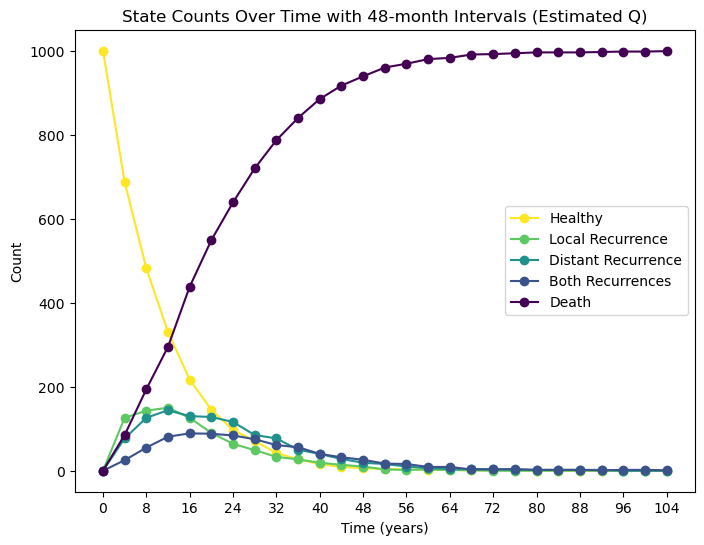

In [ ]:
# Task 12
# Simulate 1000 women, starting in state 1, until death, using the same Q
# as in the previous part. For each of the women, create a vector (or time series) of her observed states Y(i).
# A time series will consist of the values Y(i) = (X(0), X(48), X(96), . . . ,). 
# The time series should continue until death, thus the last value in each of the time series should be 5.

ctmc_samples_estimated = []
for _ in range(1000):
    print(f"Simulating sample {_+1}/1000", end="\r")
    ctmc_samples_estimated.append(simulate_ctmc(estimated_Q, initial_state=0, n_steps=-1, exit_states=[4]))

ctmc_time_series_estimated = []
for states, times in ctmc_samples_estimated:
    time_points = np.arange(0, times[-1]+1, 48)
    series = []
    for t in time_points:
        idx = np.searchsorted(times, t, side='right') - 1
        series.append(states[idx])
    ctmc_time_series_estimated.append(series)

ctmc_state_counts = np.zeros((len(estimated_Q), max(len(s) for s in ctmc_time_series_estimated)))
for series in ctmc_time_series_estimated:
    series = series + [4] * (ctmc_state_counts.shape[1] - len(series)) # pad series with dead state if shorter than max length
    for t, state in enumerate(series):
        ctmc_state_counts[state, t] += 1


plt.figure(figsize=(8, 6))
colors = ['#fde725', '#5ec962', '#21918c', '#3b528b', '#440154']

for i in range(len(estimated_Q)):
    plt.plot(ctmc_state_counts[i, :], marker='o', label=state_labels[i], color=colors[i])
plt.xticks(np.arange(0, ctmc_state_counts.shape[1],2), 4*np.arange(0, ctmc_state_counts.shape[1],2))
plt.xlabel('Time (years)')
plt.ylabel('Count')
plt.title('State Counts Over Time with 48-month Intervals (Estimated Q)')
plt.legend()
plt.show()


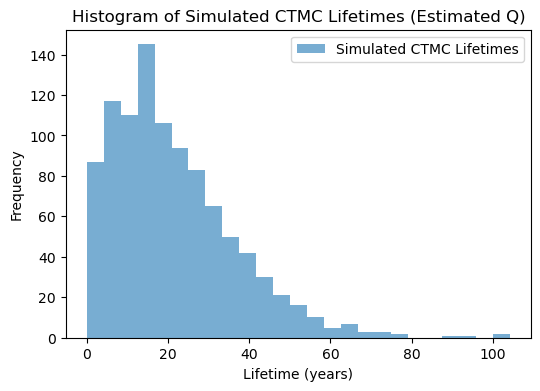

Mean lifetime: 257.4693706530522 months (or 21.455780887754347 years)
95% CI for mean lifetime: (246.08078335733265, 268.85795794877174) months
Standard deviation: 183.74763755969065 months
95% CI for standard deviation: (175.6946902547524, 191.8005848646289) months
Proportion with cancer reappeared distantly after 30.5 months: 0.46 (458 out of 1000)


In [25]:
ctmc_lifetimes_estimated = [times[-1] for states, times in ctmc_samples_estimated]
plt.figure(figsize=(6, 4))
step = int(max(ctmc_lifetimes_estimated) // 50)
hist, bins = np.histogram(ctmc_lifetimes_estimated, bins=step, range=(0, max(ctmc_lifetimes_estimated)))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.bar(bin_centers/12, hist, width=np.diff(bins)/12, alpha=0.6, label='Simulated CTMC Lifetimes')
plt.xlabel('Lifetime (years)')
plt.ylabel('Frequency')
plt.title('Histogram of Simulated CTMC Lifetimes (Estimated Q)')
plt.legend()
plt.show()

print(f"Mean lifetime: {np.mean(ctmc_lifetimes_estimated)} months (or {np.mean(ctmc_lifetimes_estimated)/12} years)")
print(f"95% CI for mean lifetime: {stats.norm.interval(0.95, loc=np.mean(ctmc_lifetimes_estimated), scale=np.std(ctmc_lifetimes_estimated)/np.sqrt(len(ctmc_lifetimes_estimated))) } months")
print(f"Standard deviation: {np.std(ctmc_lifetimes_estimated)} months")
print(f"95% CI for standard deviation: {stats.norm.interval(0.95, loc=np.std(ctmc_lifetimes_estimated), scale=np.std(ctmc_lifetimes_estimated)/np.sqrt(2*len(ctmc_lifetimes_estimated))) } months")

n_reappeared_distantly = sum(1 for states, times in ctmc_samples_estimated if times[-1] > 30.5 and 2 in states)
proportion_reappeared_distantly = n_reappeared_distantly / len(ctmc_samples_estimated)
print(f"Proportion with cancer reappeared distantly after 30.5 months: {proportion_reappeared_distantly:.2f} ({n_reappeared_distantly} out of {len(ctmc_samples_estimated)})")

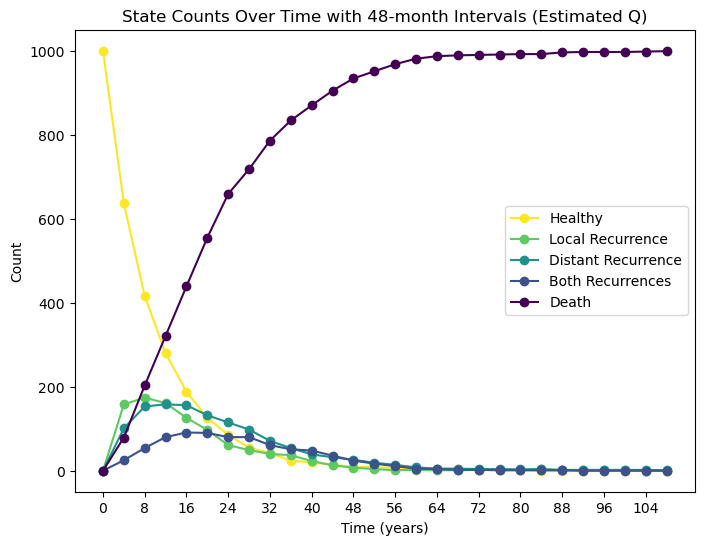

In [26]:
Q_estimated = np.array([ # taken from the estimation in the report
    [-0.0092, 0.0049, 0.0031, 0.000, 0.0012],
    [0, -0.015, 0.0063, 0.0087, 0.00],
    [0, 0.0001, -0.0087, 0.0026, 0.006],
    [0, 0.0002, 0.0, -0.012, 0.0118],
    [0, 0, 0, 0, 0]
])

ctmc_samples_estimated = []
for _ in range(1000):
    print(f"Simulating sample {_+1}/1000", end="\r")
    ctmc_samples_estimated.append(simulate_ctmc(estimated_Q, initial_state=0, n_steps=-1, exit_states=[4]))

ctmc_time_series_estimated = []
for states, times in ctmc_samples_estimated:
    time_points = np.arange(0, times[-1]+1, 48)
    series = []
    for t in time_points:
        idx = np.searchsorted(times, t, side='right') - 1
        series.append(states[idx])
    ctmc_time_series_estimated.append(series)

ctmc_state_counts = np.zeros((len(estimated_Q), max(len(s) for s in ctmc_time_series_estimated)))
for series in ctmc_time_series_estimated:
    series = series + [4] * (ctmc_state_counts.shape[1] - len(series)) # pad series with dead state if shorter than max length
    for t, state in enumerate(series):
        ctmc_state_counts[state, t] += 1


plt.figure(figsize=(8, 6))
colors = ['#fde725', '#5ec962', '#21918c', '#3b528b', '#440154']

for i in range(len(estimated_Q)):
    plt.plot(ctmc_state_counts[i, :], marker='o', label=state_labels[i], color=colors[i])
plt.xticks(np.arange(0, ctmc_state_counts.shape[1],2), 4*np.arange(0, ctmc_state_counts.shape[1],2))
plt.xlabel('Time (years)')
plt.ylabel('Count')
plt.title('State Counts Over Time with 48-month Intervals (Estimated Q)')
plt.legend()
plt.show()


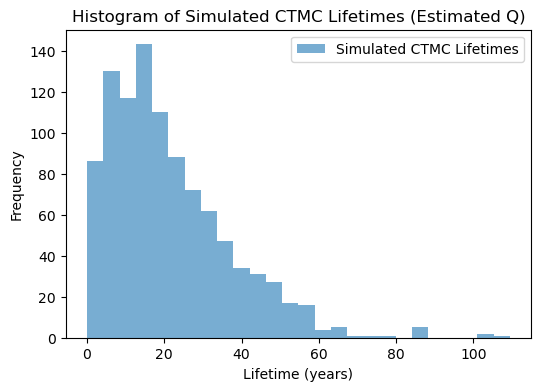

Mean lifetime: 257.7048676054451 months (or 21.47540563378709 years)
95% CI for mean lifetime: (245.90524448755423, 269.50449072333595) months
Standard deviation: 190.37944002256287 months
95% CI for standard deviation: (182.0358465004567, 198.72303354466905) months
Proportion with cancer reappeared distantly after 30.5 months: 0.46 (459 out of 1000)


In [27]:
ctmc_lifetimes_estimated = [times[-1] for states, times in ctmc_samples_estimated]
plt.figure(figsize=(6, 4))
step = int(max(ctmc_lifetimes_estimated) // 50)
hist, bins = np.histogram(ctmc_lifetimes_estimated, bins=step, range=(0, max(ctmc_lifetimes_estimated)))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.bar(bin_centers/12, hist, width=np.diff(bins)/12, alpha=0.6, label='Simulated CTMC Lifetimes')
plt.xlabel('Lifetime (years)')
plt.ylabel('Frequency')
plt.title('Histogram of Simulated CTMC Lifetimes (Estimated Q)')
plt.legend()
plt.show()

print(f"Mean lifetime: {np.mean(ctmc_lifetimes_estimated)} months (or {np.mean(ctmc_lifetimes_estimated)/12} years)")
print(f"95% CI for mean lifetime: {stats.norm.interval(0.95, loc=np.mean(ctmc_lifetimes_estimated), scale=np.std(ctmc_lifetimes_estimated)/np.sqrt(len(ctmc_lifetimes_estimated))) } months")
print(f"Standard deviation: {np.std(ctmc_lifetimes_estimated)} months")
print(f"95% CI for standard deviation: {stats.norm.interval(0.95, loc=np.std(ctmc_lifetimes_estimated), scale=np.std(ctmc_lifetimes_estimated)/np.sqrt(2*len(ctmc_lifetimes_estimated))) } months")

n_reappeared_distantly = sum(1 for states, times in ctmc_samples_estimated if times[-1] > 30.5 and 2 in states)
proportion_reappeared_distantly = n_reappeared_distantly / len(ctmc_samples_estimated)
print(f"Proportion with cancer reappeared distantly after 30.5 months: {proportion_reappeared_distantly:.2f} ({n_reappeared_distantly} out of {len(ctmc_samples_estimated)})")